# 11.2 — One-at-a-time sensitivity

**Question.** Which preserved historical configuration parameters move selected-policy outcomes beyond baseline optimizer noise? The `test` profile runs one parameter grid on synthetic cells; larger profiles use the prespecified screening/full grids and env-resolved features. The exact count is previewed before execution.

The shared runner resumes signed artifacts under the legacy sensitivity root. Response curves are conditional OAT diagnostics: they do not capture parameter interactions, establish causal effects, or convert dimensionless model settings into empirical uncertainty. Run 11.1 at the same output root first so effect-to-noise ratios use fixed-default seed variation.

In [1]:
import os
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from estonia_landuse.sensitivity.analysis import select_matched_baseline_runs, summarize_oat
from estonia_landuse.sensitivity.config import DEFAULT_SEEDS, OAT_PARAMETERS
from estonia_landuse.sensitivity.plots import plot_oat_response_curves
from estonia_landuse.sensitivity.runner import run_manifest
from estonia_landuse.sensitivity.sampling import build_oat_manifest, manifest_run_count, manifest_summary

PROJECT_ROOT = Path.cwd().resolve()
if PROJECT_ROOT.name == "notebooks": PROJECT_ROOT = PROJECT_ROOT.parent
HISTORICAL_ROOT = PROJECT_ROOT.parent.parent if PROJECT_ROOT.parent.name == ".worktrees" else PROJECT_ROOT
PROFILE = os.environ.get("SENSITIVITY_PROFILE", "test")
PROFILE = os.environ.get("SENSITIVITY_PROFILE", "full")
N_WORKERS = int(os.environ.get("SENSITIVITY_N_WORKERS", "4"))
OVERWRITE = os.environ.get("SENSITIVITY_OVERWRITE", "false").lower() == "true"
OUTPUT_ROOT = Path(os.environ.get("SENSITIVITY_OUTPUT_ROOT", PROJECT_ROOT / "data/processed/legacy_sensitivity")).resolve()
FEATURES_PATH = Path(os.environ.get("SENSITIVITY_FEATURES_PATH", HISTORICAL_ROOT / "data/processed/learned_carbon/features_with_forest.parquet")).resolve()
SEEDS = (0, 1) if PROFILE == "test" else DEFAULT_SEEDS[PROFILE]
SCENARIOS = ("balanced",)
OUTCOMES = ("biodiversity_gain", "carbon_gain", "cost", "changed_pct")


In [2]:
if PROFILE == "test":
    position = np.linspace(0.0, 1.0, 12)
    context = pd.DataFrame({"cell_id": np.arange(1, 13), "forest_pct": 0.35 + 0.03 * position, "wetland_pct": 0.10 + 0.02 * position, "agriculture_pct": 0.30 - 0.03 * position, "grassland_pct": 0.15 - 0.02 * position, "urban_pct": np.full(12, 0.05), "water_pct": np.full(12, 0.05), "protected_overlap_pct": 0.05 * position, "wetland_suitability": 0.2 + 0.6 * position, "opportunity_cost_proxy": 0.1 + 0.5 * position, "predicted_tco2_ha_yr": 2.5 + 2.0 * position, "peat_overlap_pct": 0.4 * position})
    feature_columns = ["wetland_suitability", "opportunity_cost_proxy"]
else:
    if not FEATURES_PATH.exists(): raise FileNotFoundError(f"Missing historical feature input: {FEATURES_PATH}")
    context = pd.read_parquet(FEATURES_PATH)
    feature_columns = [name for name in ("urban_pct", "agriculture_pct", "grassland_pct", "forest_pct", "wetland_pct", "water_pct", "naturalness_score", "carbon_score", "protected_overlap_pct", "wetland_suitability", "biodiversity_proxy", "opportunity_cost_proxy", "rohemeeter_norm") if name in context]
    if not feature_columns: raise ValueError("No preserved Notebook 10 feature columns found")


In [3]:
manifest = build_oat_manifest(profile=PROFILE, scenarios=SCENARIOS, seeds=SEEDS)
if PROFILE == "test":
    manifest = manifest.loc[manifest["parameter"].eq(next(iter(OAT_PARAMETERS)))].reset_index(drop=True)
planned_runs = manifest_run_count(manifest)
manifest_summary(manifest)
display(manifest.head(6))


oat: 108 optimizer runs (profile=full)


,experiment,sample_id,scenario,seed,profile,parameter,value,overrides,status
0,oat,oat__scoring.base_change_cost__0.0,balanced,42,full,scoring.base_change_cost,0.0,{'scoring.base_change_cost': 0.0},pending
1,oat,oat__scoring.base_change_cost__0.0,balanced,73,full,scoring.base_change_cost,0.0,{'scoring.base_change_cost': 0.0},pending
2,oat,oat__scoring.base_change_cost__0.0,balanced,101,full,scoring.base_change_cost,0.0,{'scoring.base_change_cost': 0.0},pending
3,oat,oat__scoring.base_change_cost__0.1,balanced,42,full,scoring.base_change_cost,0.1,{'scoring.base_change_cost': 0.1},pending
4,oat,oat__scoring.base_change_cost__0.1,balanced,73,full,scoring.base_change_cost,0.1,{'scoring.base_change_cost': 0.1},pending
5,oat,oat__scoring.base_change_cost__0.1,balanced,101,full,scoring.base_change_cost,0.1,{'scoring.base_change_cost': 0.1},pending


In [4]:
statuses = run_manifest(context, feature_columns, manifest, OUTPUT_ROOT, PROFILE, overwrite=OVERWRITE, n_workers=min(N_WORKERS, planned_runs), progress=lambda completed, total, status: print(f"[{completed}/{total}] {status}"))
if statuses["status"].eq("failed").any(): raise RuntimeError(statuses.loc[statuses["status"].eq("failed"), ["sample_id", "seed", "error_message"]].to_string(index=False))
assert len(statuses) == planned_runs
display(statuses["status"].value_counts())


[1/108] completed
[2/108] completed
[3/108] completed
[4/108] completed
[5/108] completed
[6/108] completed
[7/108] completed
[8/108] completed
[9/108] completed
[10/108] completed
[11/108] completed
[12/108] completed
[13/108] completed
[14/108] completed
[15/108] completed
[16/108] completed
[17/108] completed
[18/108] completed
[19/108] completed
[20/108] completed
[21/108] completed
[22/108] completed
[23/108] completed
[24/108] completed
[25/108] completed
[26/108] completed
[27/108] completed
[28/108] completed
[29/108] completed
[30/108] completed
[31/108] completed
[32/108] completed
[33/108] completed
[34/108] completed
[35/108] completed
[36/108] completed
[37/108] completed
[38/108] completed
[39/108] completed
[40/108] completed
[41/108] completed
[42/108] completed
[43/108] completed
[44/108] completed
[45/108] completed
[46/108] completed
[47/108] completed
[48/108] completed
[49/108] completed
[50/108] completed
[51/108] completed
[52/108] completed
[53/108] completed
[5

status
completed    108
Name: count, dtype: int64

,scenario,parameter,outcome,minimum_mean,maximum_mean,effect_range,baseline_sd,effect_to_noise
15,balanced,scoring.agriculture_loss_cost,cost,0.090404,0.298705,0.208301,0.013346,15.608306
12,balanced,scoring.agriculture_loss_cost,biodiversity_gain,0.006061,0.014173,0.008112,0.000783,10.357967
27,balanced,scoring.max_agriculture_loss_pct,cost,0.099010,0.215999,0.116988,0.013346,8.766110
19,balanced,scoring.base_change_cost,cost,0.098126,0.212651,0.114525,0.013346,8.581493
8,balanced,max_changed_pct,biodiversity_gain,0.006331,0.012649,0.006318,0.000783,8.068116
24,balanced,scoring.max_agriculture_loss_pct,biodiversity_gain,0.008658,0.013343,0.004684,0.000783,5.981620
9,balanced,max_changed_pct,carbon_gain,0.008933,0.026602,0.017669,0.003084,5.729462
10,balanced,max_changed_pct,changed_pct,0.033441,0.074337,0.040895,0.007521,5.437473
11,balanced,max_changed_pct,cost,0.080975,0.141353,0.060378,0.013346,4.524215
13,balanced,scoring.agriculture_loss_cost,carbon_gain,0.014305,0.024288,0.009983,0.003084,3.237170


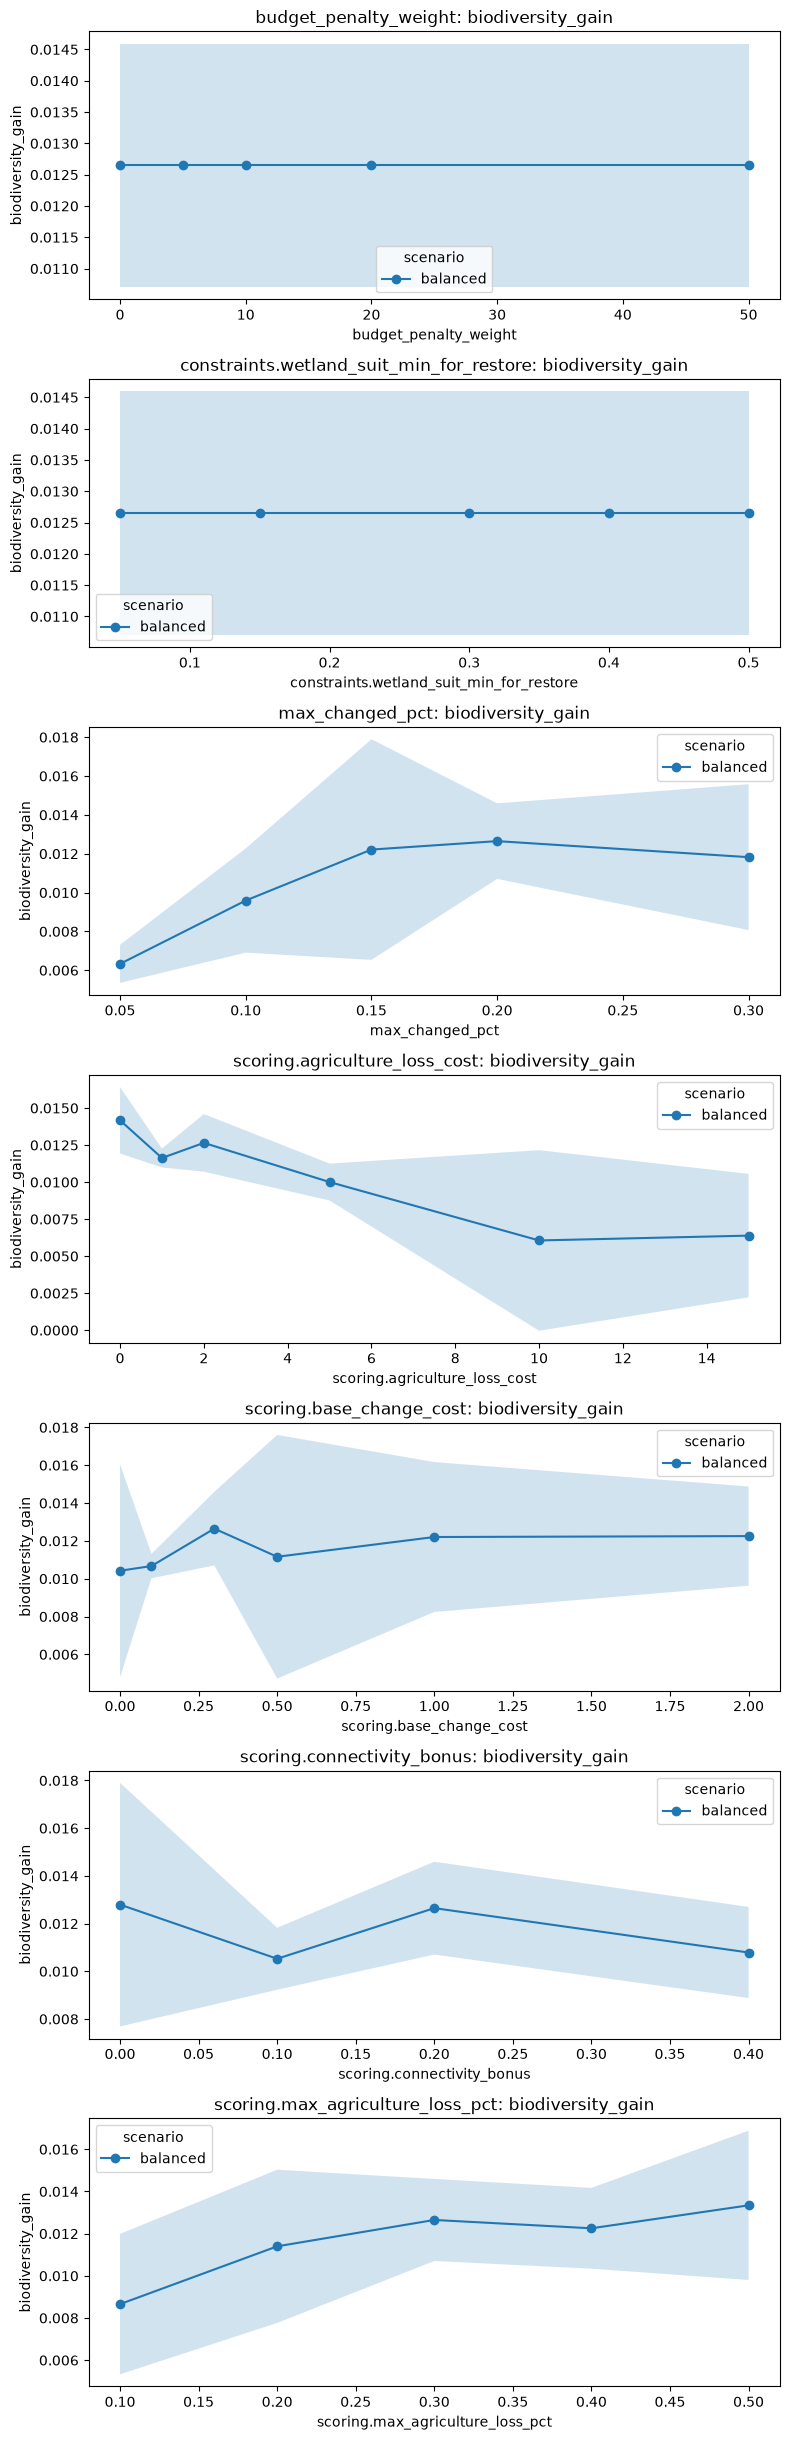

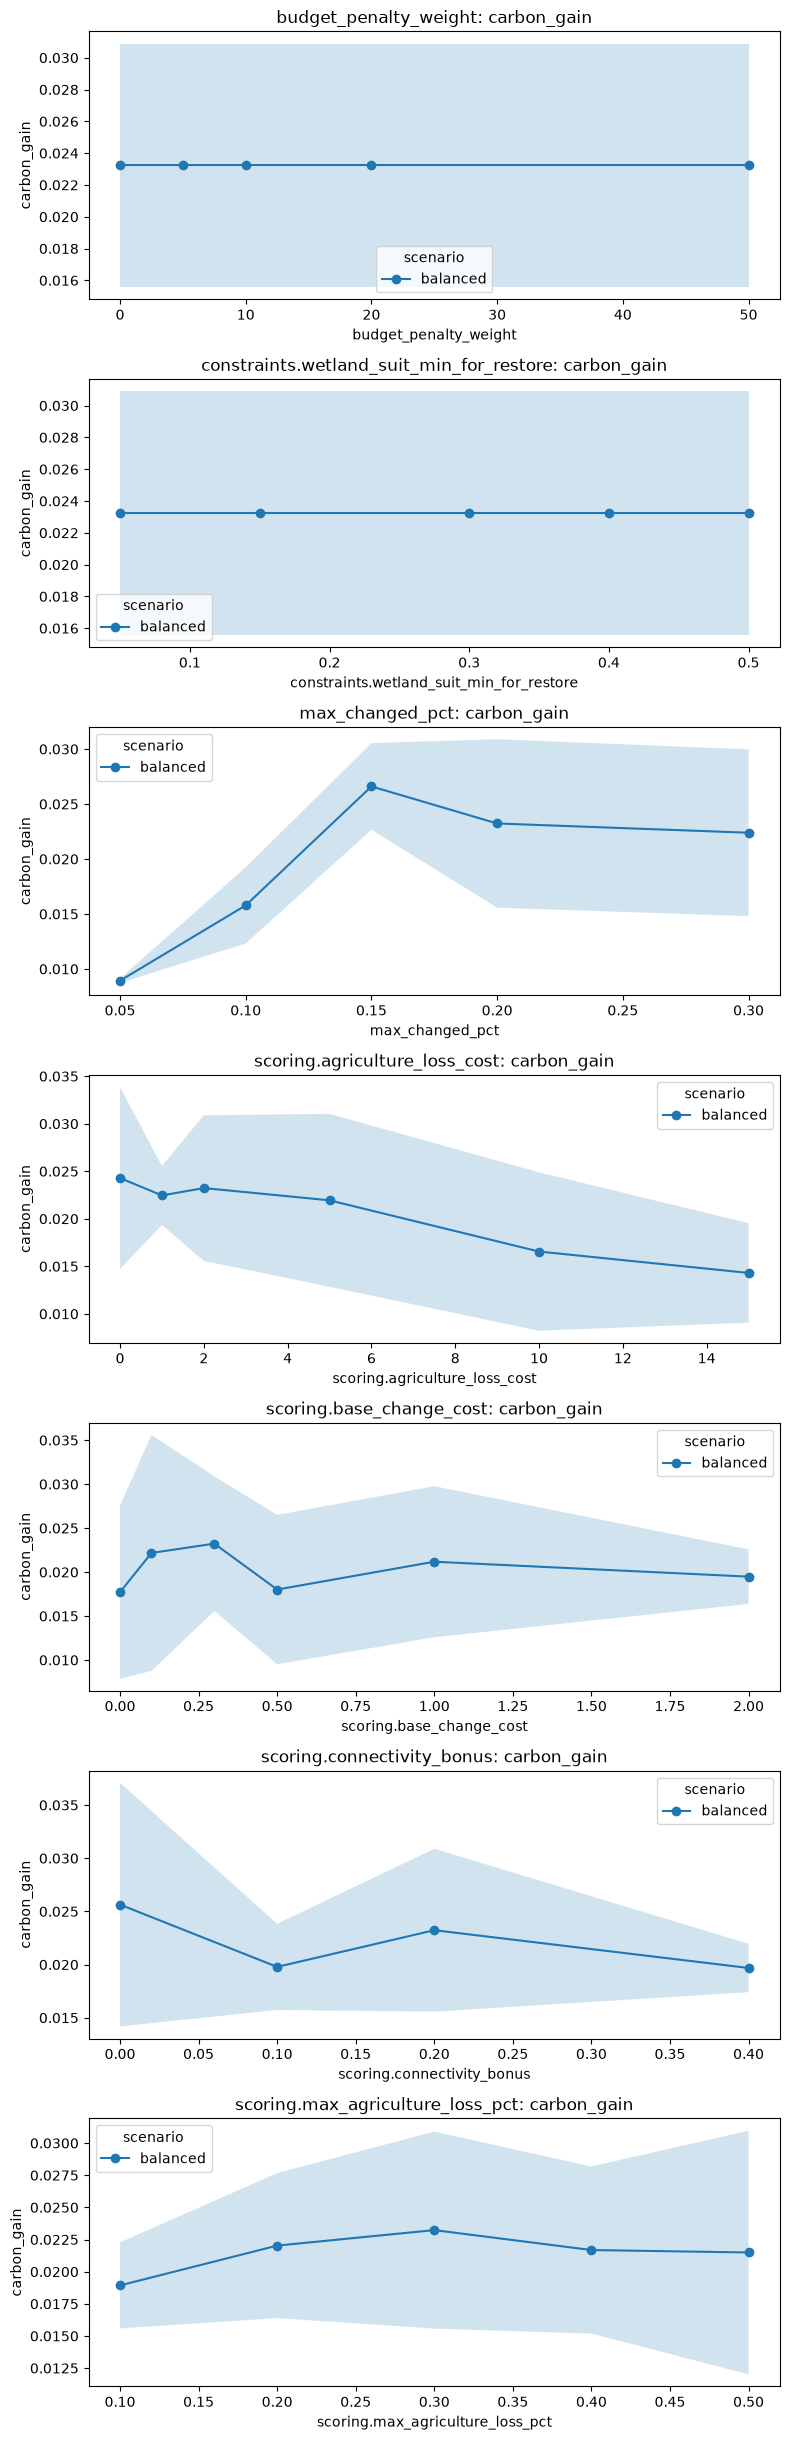

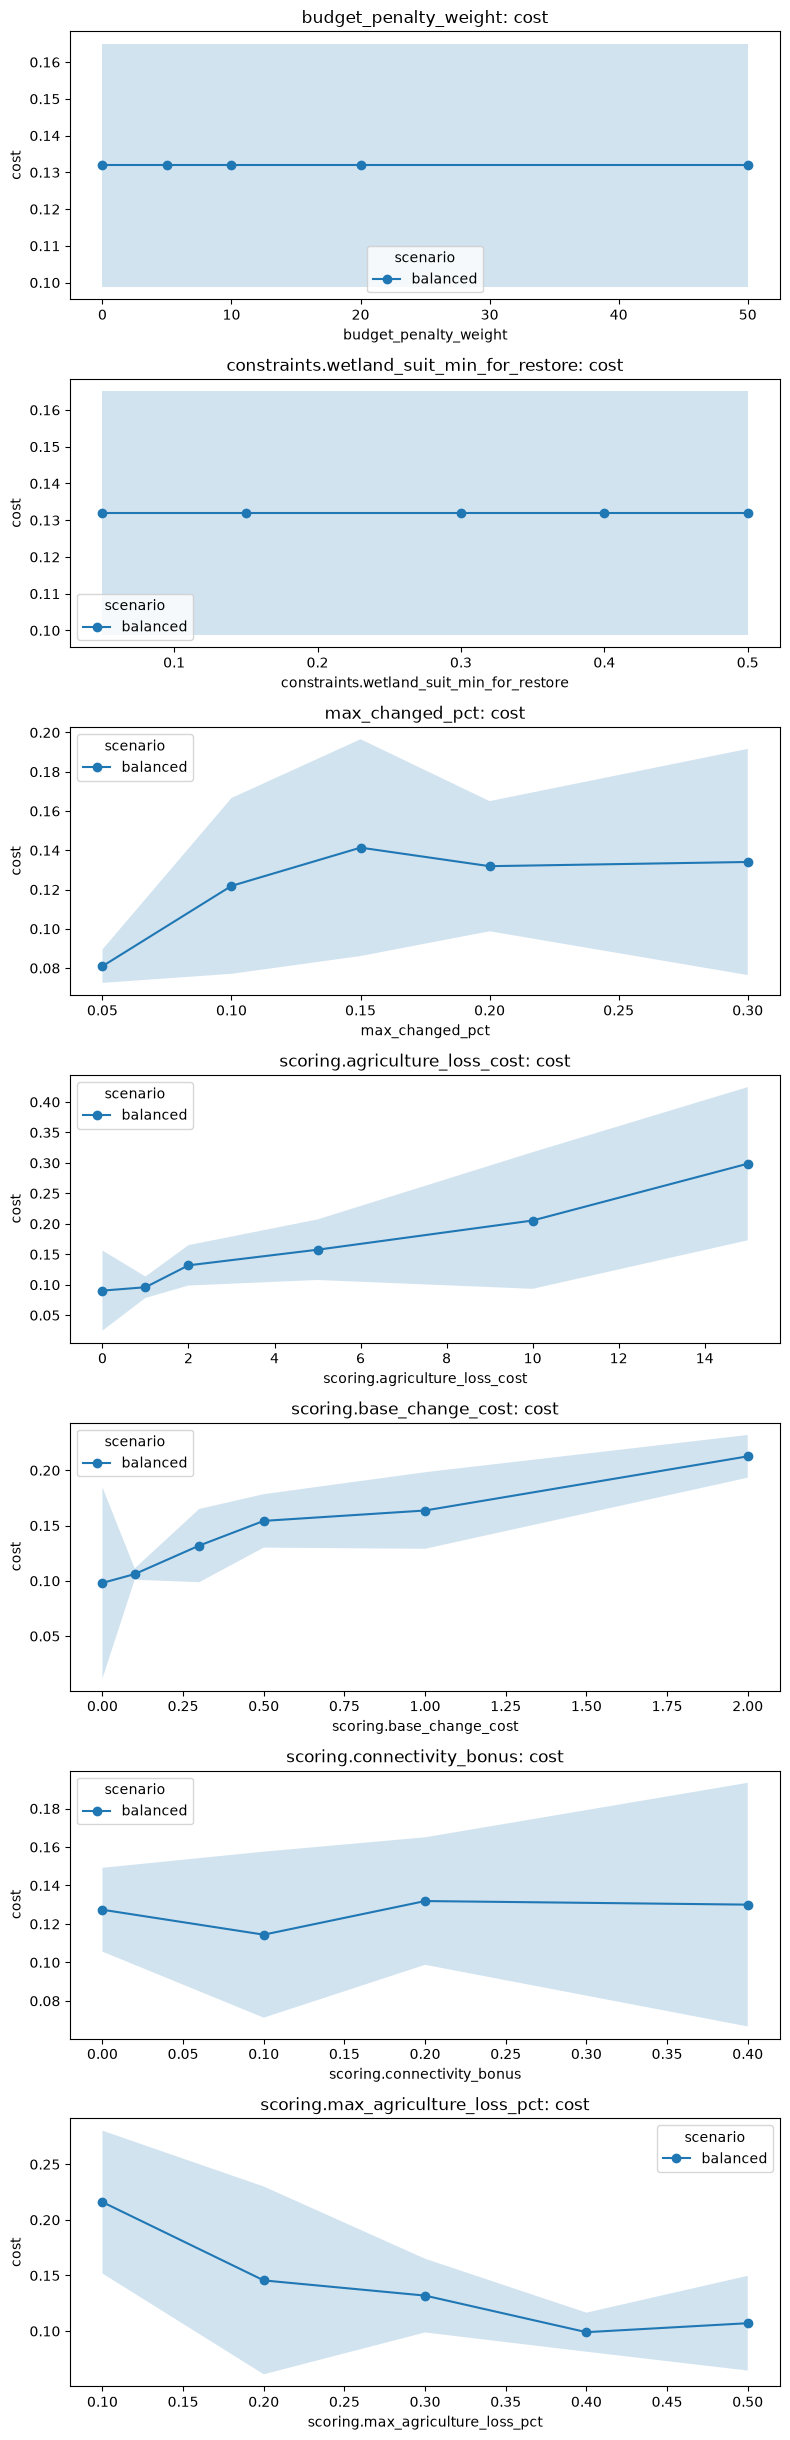

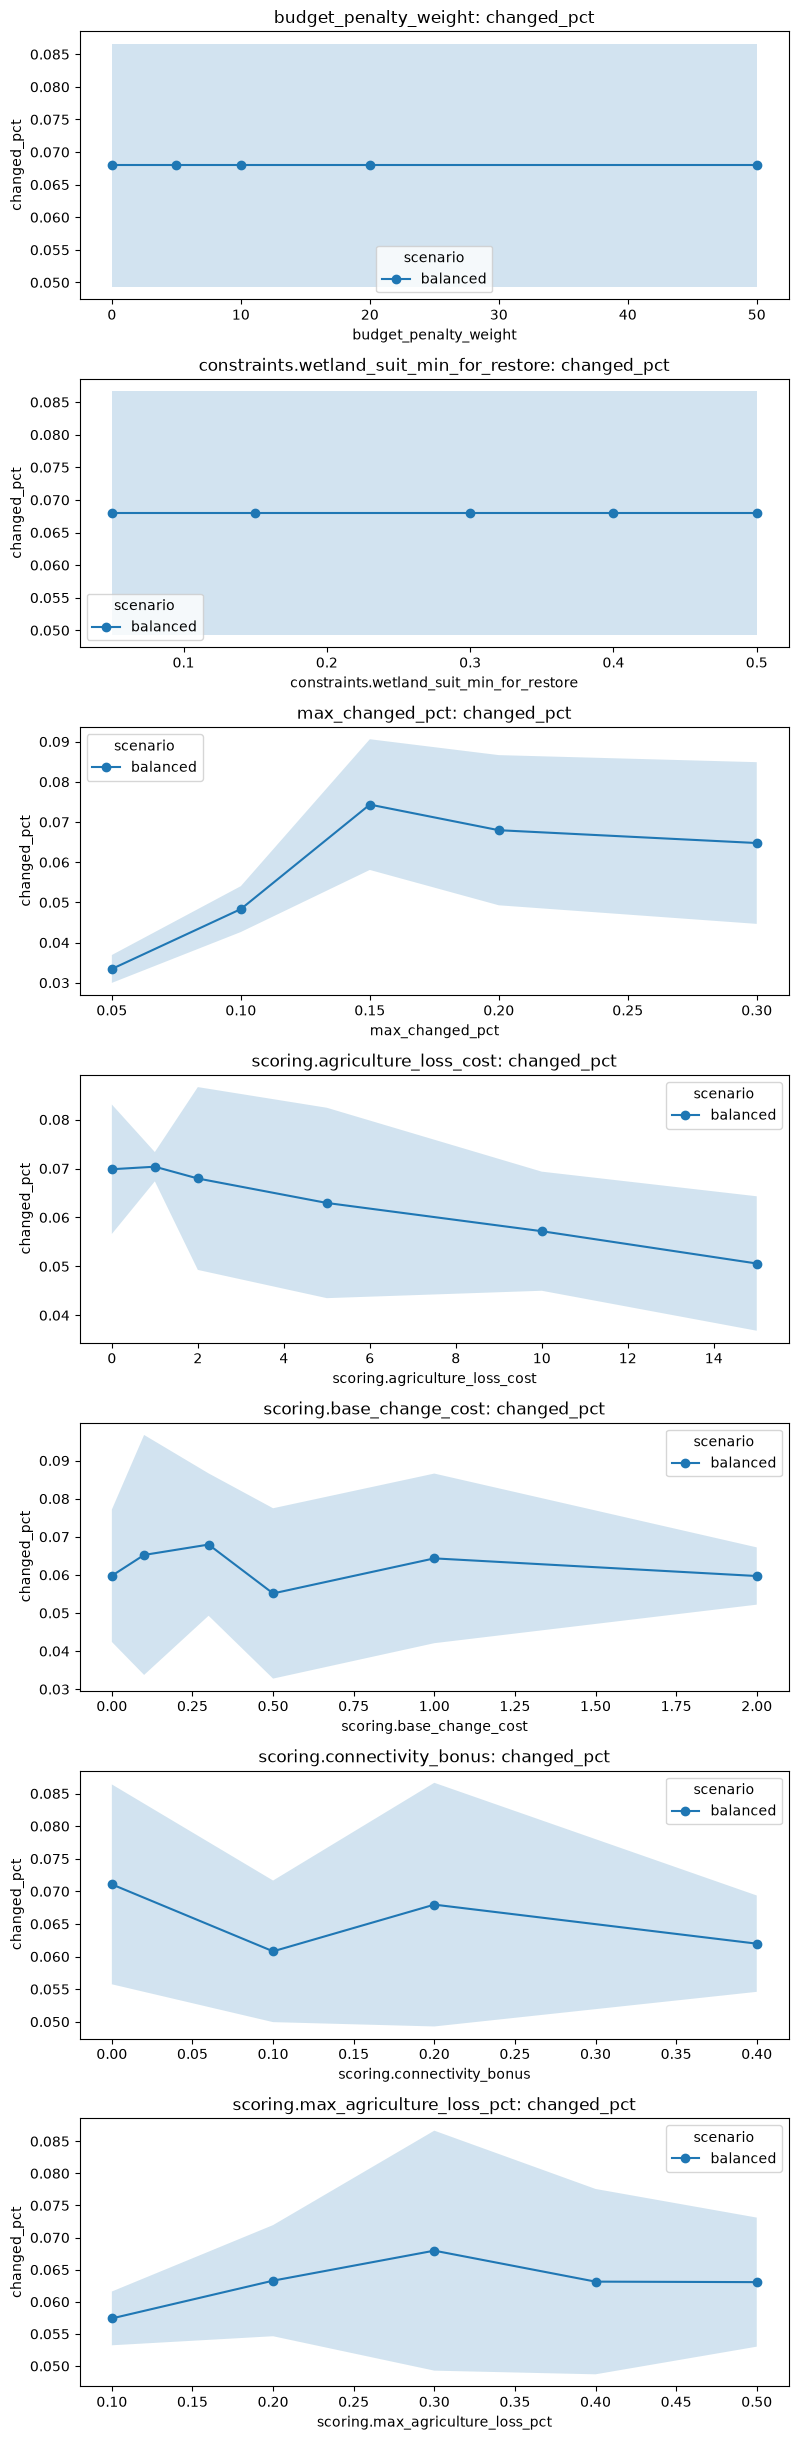

In [5]:
metrics = pd.concat([pd.read_parquet(path) for path in statuses["metrics_path"]], ignore_index=True)
baseline_paths = sorted((OUTPUT_ROOT / "runs" / "baseline").rglob("seed_*.parquet"))
if not baseline_paths: raise FileNotFoundError("Run Notebook 11.1 with this SENSITIVITY_OUTPUT_ROOT first")
baseline_candidates = pd.concat([pd.read_parquet(path) for path in baseline_paths], ignore_index=True)
baseline = select_matched_baseline_runs(
    baseline_candidates, metrics, expected_scenarios=SCENARIOS, expected_seeds=SEEDS
)
curves, effect_to_noise = summarize_oat(metrics, baseline, OUTCOMES)
display(effect_to_noise.sort_values("effect_to_noise", ascending=False))
for outcome in OUTCOMES:
    figure, _ = plot_oat_response_curves(curves, outcome)
    display(figure)
    plt.close(figure)
